# 1. Lançamento Oblíquo: O Impacto da Resistência do Ar

Na física de ensino médio, geralmente ignoramos a resistência do ar para simplificar as contas, assumindo que a única força atuando sobre o projétil é a gravidade. No entanto, no mundo real, a força de arrasto do ar muda completamente a trajetória de um objeto.

Nesta simulação, vamos usar o Python para resolver as equações de movimento numericamente e comparar duas trajetórias:
1. **Trajetória Ideal:** No vácuo (apenas força peso).
2. **Trajetória Real:** Com resistência do ar proporcional ao quadrado da velocidade.

### A Física por trás do código

A Segunda Lei de Newton para o projétil sujeito à força de arrasto é dada por:

$$m\frac{d\vec{v}}{dt} = m\vec{g} - \frac{1}{2}\rho C_d A |\vec{v}|\vec{v}$$

Onde:
* $m$ é a massa do projétil.
* $\vec{g}$ é a aceleração da gravidade.
* $\rho$ é a densidade do ar.
* $C_d$ é o coeficiente de arrasto (depende do formato do objeto).
* $A$ é a área de seção transversal do objeto.
* $\vec{v}$ é o vetor velocidade do projétil.

Para facilitar a simulação, agrupamos as constantes do ar e do objeto em um único coeficiente $k$. Assim, podemos decompor a aceleração nos eixos $x$ e $y$:

$$\frac{dv_x}{dt} = -k \sqrt{v_x^2 + v_y^2} v_x$$
$$\frac{dv_y}{dt} = -g - k \sqrt{v_x^2 + v_y^2} v_y$$

Como essas equações não possuem uma solução analítica simples, vamos usar o pacote `scipy` para resolvê-las numericamente ao longo do tempo!

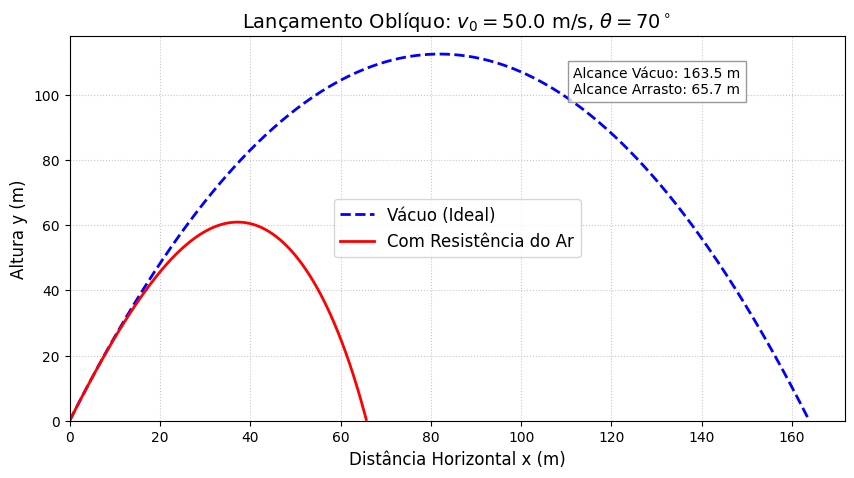

In [2]:
# Importando as bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==========================================
# 1. DEFINIÇÃO DOS PARÂMETROS DA SIMULAÇÃO
# ==========================================
g = 9.81      # Aceleração da gravidade (m/s^2)
m = 0.145     # Massa de uma bola de beisebol (kg)
rho = 1.225   # Densidade do ar ao nível do mar (kg/m^3)
Cd = 0.47     # Coeficiente de arrasto de uma esfera
r = 0.0366    # Raio da bola de beisebol (m)
A = np.pi * r**2 # Área de seção transversal (m^2)

# Constante de arrasto k = (1/2 * rho * Cd * A) / m
k = (0.5 * rho * Cd * A) / m

# Condições Iniciais do Lançamento
v0 = 50.0                # Velocidade inicial (m/s)
theta_graus = 70       # Ângulo de lançamento em graus
theta = np.radians(theta_graus) # Convertendo para radianos

# Componentes da velocidade inicial (v0x, v0y)
v0x = v0 * np.cos(theta)
v0y = v0 * np.sin(theta)

# O estado inicial do sistema é uma lista: [posição_x, posição_y, vel_x, vel_y]
estado_inicial = [0.0, 0.0, v0x, v0y]

# Tempo máximo de simulação (segundos) e pontos de avaliação
t_span = (0, 10)
t_eval = np.linspace(0, 10, 500)

# ==========================================
# 2. DEFINIÇÃO DAS EQUAÇÕES DIFERENCIAIS
# ==========================================

# Função para o lançamento no vácuo (Sem Arrasto)
def vacuo(t, estado):
    x, y, vx, vy = estado
    ax = 0.0      # Nenhuma força no eixo x
    ay = -g       # Apenas a gravidade no eixo y
    return [vx, vy, ax, ay]

# Função para o lançamento no ar (Com Arrasto)
def com_arrasto(t, estado):
    x, y, vx, vy = estado
    v_modulo = np.sqrt(vx**2 + vy**2) # Módulo da velocidade atual

    # Acelerações usando a fórmula da decomposição de vetores
    ax = -k * v_modulo * vx
    ay = -g - k * v_modulo * vy

    return [vx, vy, ax, ay]

# Evento para parar a simulação quando a bola tocar o chão (y = 0)
def chao(t, estado):
    return estado[1] # Retorna a posição y
chao.terminal = True # Força a parada da integração quando y passar por zero
chao.direction = -1  # Apenas se estiver caindo (passando de positivo para negativo)

# ==========================================
# 3. RESOLUÇÃO NUMÉRICA DAS EQUAÇÕES
# ==========================================

# Resolvendo para o vácuo
sol_vacuo = solve_ivp(vacuo, t_span, estado_inicial, t_eval=t_eval, events=chao)

# Resolvendo para o modelo com arrasto
sol_arrasto = solve_ivp(com_arrasto, t_span, estado_inicial, t_eval=t_eval, events=chao)

# ==========================================
# 4. PLOTAGEM DOS RESULTADOS E VISUALIZAÇÃO
# ==========================================
plt.figure(figsize=(10, 5))

# Plotando a trajetória ideal (Vácuo)
plt.plot(sol_vacuo.y[0], sol_vacuo.y[1], 'b--', label='Vácuo (Ideal)', linewidth=2)

# Plotando a trajetória real (Com arrasto)
plt.plot(sol_arrasto.y[0], sol_arrasto.y[1], 'r-', label='Com Resistência do Ar', linewidth=2)

# Configurações do gráfico para ficar bonito para os alunos
plt.title(f'Lançamento Oblíquo: $v_0 = {v0}$ m/s, $\\theta = {theta_graus}^\\circ$', fontsize=14)
plt.xlabel('Distância Horizontal x (m)', fontsize=12)
plt.ylabel('Altura y (m)', fontsize=12)
plt.xlim(left=0)   # O eixo X usa 'left' para definir o início
plt.ylim(bottom=0) # O eixo Y usa 'bottom' para definir a base
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

# Exibindo o alcance máximo alcançado em ambos os casos
alcance_vacuo = sol_vacuo.y[0][-1]
alcance_arrasto = sol_arrasto.y[0][-1]

# Adicionando um texto explicativo diretamente dentro do gráfico
texto_resultados = (f'Alcance Vácuo: {alcance_vacuo:.1f} m\n'
                    f'Alcance Arrasto: {alcance_arrasto:.1f} m')
plt.text(0.65, 0.85, texto_resultados, transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.show()

# 2. Oscilador Harmônico Amortecido

Na sala de aula, frequentemente estudamos o Oscilador Harmônico Simples (MHS), onde uma massa presa a uma mola oscila infinitamente porque não há perda de energia. Na realidade, forças de atrito (como a resistência do ar ou o amortecedor de um carro) dissipam essa energia, fazendo a oscilação decair com o tempo.

Neste exemplo, vamos simular e visualizar os três regimes de amortecimento:
1. **Subamortecido:** O sistema oscila, mas a amplitude diminui com o tempo.
2. **Criticamente Amortecido:** O sistema retorna ao ponto de equilíbrio o mais rápido possível sem oscilar.
3. **Superamortecido:** O atrito é tão grande que o sistema retorna lentamente ao ponto de equilíbrio, sem oscilar.

### A Matemática do Sistema

Pela Segunda Lei de Newton, a soma das forças (Força Elástica + Força de Amortecimento) é igual à massa vezes a aceleração:

$$-kx - c\frac{dx}{dt} = m\frac{d^2x}{dt^2}$$

Reorganizando, temos a equação diferencial de segunda ordem clássica:

$$m\frac{d^2x}{dt^2} + c\frac{dx}{dt} + kx = 0$$

Onde:
* $m$ é a massa.
* $c$ é a constante de amortecimento.
* $k$ é a constante elástica da mola.
* $x$ é a posição em relação ao ponto de equilíbrio.

Para resolvermos isso no Python, transformamos essa equação de segunda ordem em um sistema de duas equações de primeira ordem:
* A taxa de variação da posição é a velocidade: $\frac{dx}{dt} = v$
* A taxa de variação da velocidade é a aceleração: $\frac{dv}{dt} = -\frac{c}{m}v - \frac{k}{m}x$

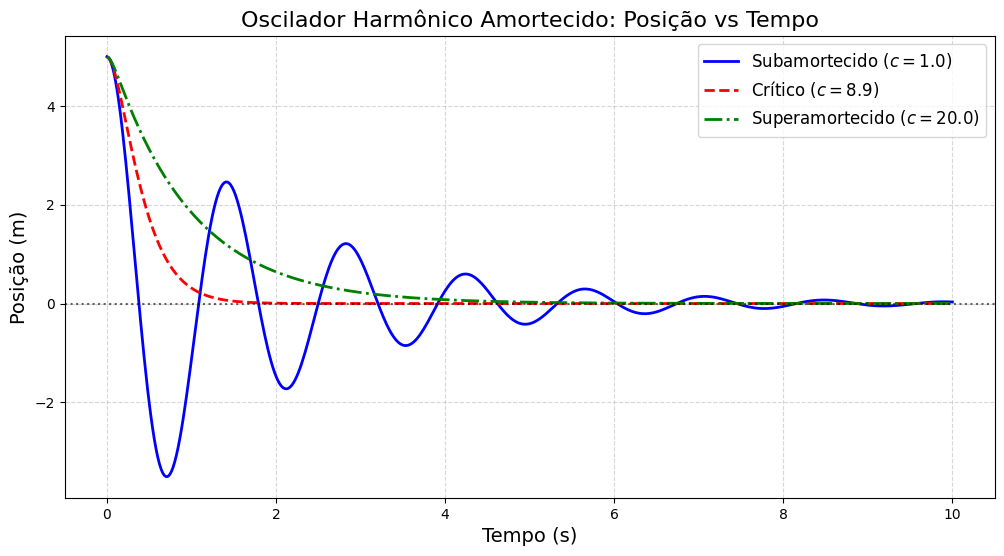

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==========================================
# 1. PARÂMETROS FÍSICOS DO SISTEMA
# ==========================================
m = 1.0   # Massa (kg)
k = 20.0  # Constante elástica da mola (N/m)

# O coeficiente de amortecimento crítico é dado por c_critico = 2 * sqrt(m * k)
c_critico = 2 * np.sqrt(m * k)

# Vamos testar três valores diferentes de 'c' para ver os três comportamentos
c_sub = 1.0           # Menor que o crítico (Subamortecido)
c_crit = c_critico    # Igual ao crítico (Criticamente Amortecido)
c_super = 20.0        # Maior que o crítico (Superamortecido)

# Condições Iniciais
x0 = 5.0  # Posição inicial (m) - a mola foi esticada
v0 = 0.0  # Velocidade inicial (m/s) - partindo do repouso
estado_inicial = [x0, v0]

# Tempo de simulação (0 a 10 segundos)
t_span = (0, 10)
t_eval = np.linspace(0, 10, 500)

# ==========================================
# 2. DEFINIÇÃO DA EQUAÇÃO DIFERENCIAL
# ==========================================

# Criamos uma função geradora para facilitar a troca do valor de 'c'
def criar_oscilador(c):
    def oscilador(t, estado):
        x, v = estado
        dxdt = v
        # dv/dt = -(c/m)*v - (k/m)*x
        dvdt = -(c / m) * v - (k / m) * x
        return [dxdt, dvdt]
    return oscilador

# ==========================================
# 3. RESOLUÇÃO NUMÉRICA
# ==========================================

# Resolvemos a equação para os três casos
sol_sub = solve_ivp(criar_oscilador(c_sub), t_span, estado_inicial, t_eval=t_eval)
sol_crit = solve_ivp(criar_oscilador(c_crit), t_span, estado_inicial, t_eval=t_eval)
sol_super = solve_ivp(criar_oscilador(c_super), t_span, estado_inicial, t_eval=t_eval)

# ==========================================
# 4. PLOTAGEM DOS RESULTADOS
# ==========================================
plt.figure(figsize=(12, 6))

# Plotando as três curvas
plt.plot(sol_sub.t, sol_sub.y[0], 'b-', linewidth=2, label=f'Subamortecido ($c = {c_sub}$)')
plt.plot(sol_crit.t, sol_crit.y[0], 'r--', linewidth=2, label=f'Crítico ($c = {c_crit:.1f}$)')
plt.plot(sol_super.t, sol_super.y[0], 'g-.', linewidth=2, label=f'Superamortecido ($c = {c_super}$)')

# Linha pontilhada preta marcando o ponto de equilíbrio (x = 0)
plt.axhline(0, color='black', linestyle=':', alpha=0.6)

# Configurações do gráfico
plt.title('Oscilador Harmônico Amortecido: Posição vs Tempo', fontsize=16)
plt.xlabel('Tempo (s)', fontsize=14)
plt.ylabel('Posição (m)', fontsize=14)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# 3. Física Moderna: O Efeito Fotoelétrico

Até o final do século XIX, a luz era considerada puramente uma onda contínua. Porém, essa teoria falhava ao explicar o **Efeito Fotoelétrico** — a emissão de elétrons por um material quando iluminado.

Em 1905, Albert Einstein resolveu o problema propondo que a luz é composta por pacotes discretos de energia, os **fótons**. A energia de um fóton é diretamente proporcional à sua frequência:

$$E = hf$$

Onde:
* $E$ é a energia do fóton.
* $h$ é a constante de Planck ($4.136 \times 10^{-15} \text{ eV}\cdot\text{s}$).
* $f$ é a frequência da luz incidente.

Para que um elétron seja ejetado do metal, o fóton precisa ter uma energia maior que a **Função Trabalho ($\Phi$)**, que é a "energia de ligação" mínima que prende o elétron ao material. A energia que sobra vira a energia cinética máxima ($K_{max}$) do elétron ejetado:

$$K_{max} = hf - \Phi$$

Se $hf < \Phi$, nenhuma emissão ocorre, independentemente de quão intensa seja a luz. A frequência exata em que $hf = \Phi$ é chamada de **frequência de corte ($f_0$)**.

Vamos simular e visualizar isso para três metais reais: Sódio, Zinco e Cobre.

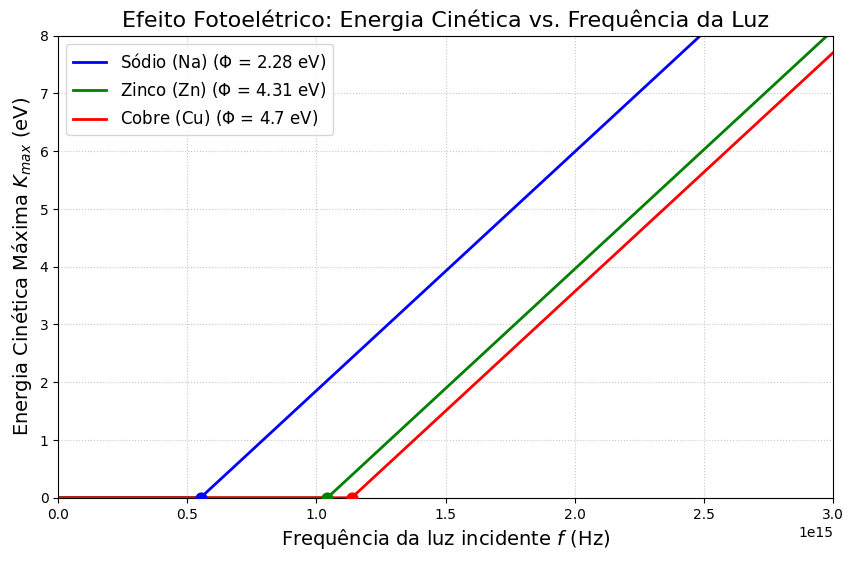

In [4]:
# Importando as bibliotecas
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. CONSTANTES FÍSICAS E PARÂMETROS
# ==========================================
# Constante de Planck em elétron-volts por segundo (eV.s)
# Usamos eV porque é a unidade padrão para energias em nível atômico
h = 4.135667696e-15

# Dicionário contendo os metais e suas respectivas Funções Trabalho (Phi) em eV
metais = {
    'Sódio (Na)': 2.28,
    'Zinco (Zn)': 4.31,
    'Cobre (Cu)': 4.70
}

# Criando um vetor de frequências (eixo X)
# Vamos varrer de 0 até 30 * 10^14 Hz (abrange do infravermelho até o ultravioleta)
frequencias = np.linspace(0, 30e14, 500)

# ==========================================
# 2. CÁLCULO E PLOTAGEM DOS DADOS
# ==========================================
plt.figure(figsize=(10, 6))

# Definindo cores para cada metal para o gráfico ficar didático
cores = ['blue', 'green', 'red']

for (nome, phi), cor in zip(metais.items(), cores):

    # 1. Calculando a Energia Cinética (K = hf - Phi)
    # Convertendo a energia do fóton (hf) e subtraindo a função trabalho
    energia_cinetica = h * frequencias - phi

    # Na física real, se a energia do fóton for menor que Phi, o elétron não sai.
    # Portanto, a energia cinética não pode ser negativa. Vamos zerar os valores menores que 0.
    energia_cinetica = np.maximum(0, energia_cinetica)

    # 2. Plotando a linha da Energia Cinética vs Frequência
    plt.plot(frequencias, energia_cinetica, label=f'{nome} ($\\Phi$ = {phi} eV)',
             color=cor, linewidth=2)

    # 3. Calculando e marcando a Frequência de Corte (f0)
    # É o ponto exato onde a linha toca o eixo X (K = 0) -> f0 = Phi / h
    f0 = phi / h
    plt.scatter(f0, 0, color=cor, s=60, zorder=5) # s é o tamanho do ponto, zorder coloca o ponto na frente da linha

# ==========================================
# 3. ESTILIZAÇÃO DO GRÁFICO
# ==========================================
plt.title('Efeito Fotoelétrico: Energia Cinética vs. Frequência da Luz', fontsize=16)

# Usando notação científica no eixo X para facilitar a leitura para os alunos
plt.xlabel('Frequência da luz incidente $f$ (Hz)', fontsize=14)
plt.ylabel('Energia Cinética Máxima $K_{max}$ (eV)', fontsize=14)

plt.xlim(left=0, right=30e14)
plt.ylim(bottom=0, top=8)

# Colocando uma malha de fundo para facilitar a leitura dos valores
plt.grid(True, linestyle=':', alpha=0.7)

# Adicionando a legenda
plt.legend(fontsize=12, loc='upper left')

# Mostrando o gráfico na tela
plt.show()

# 4. Relatividade Restrita: Dilatação do Tempo

Em 1905, Einstein revolucionou a física ao postular que a velocidade da luz no vácuo ($c$) é a mesma para todos os observadores, independentemente do seu movimento. Isso leva a uma consequência chocante: o tempo não é absoluto.

### O Fator de Lorentz ($\gamma$)

A peça chave da relatividade é o **Fator de Lorentz**, que dita o quanto o tempo dilata ou o comprimento contrai. Ele é definido como:

$$\gamma = \frac{1}{\sqrt{1 - \frac{v^2}{c^2}}}$$

Onde:
* $v$ é a velocidade do objeto.
* $c$ é a velocidade da luz ($\approx 3 \times 10^8$ m/s).

### Dilatação do Tempo e Contração do Comprimento

1. **Dilatação do Tempo:** Um intervalo de tempo medido por um observador em repouso ($\Delta t$) é maior que o tempo medido no referencial em movimento ($\Delta t_0$):
   $$\Delta t = \gamma \Delta t_0$$
   *"Relógios em movimento correm mais devagar."*

2. **Contração do Comprimento:** O comprimento de um objeto em movimento ($L$) parece menor para um observador parado do que o seu comprimento próprio ($L_0$):
   $$L = \frac{L_0}{\gamma}$$

Vamos visualizar como o fator $\gamma$ se comporta e aplicar isso em um cenário de viagem interestelar.

<>:29: SyntaxWarning: invalid escape sequence '\g'
<>:31: SyntaxWarning: invalid escape sequence '\g'
<>:39: SyntaxWarning: invalid escape sequence '\g'
<>:29: SyntaxWarning: invalid escape sequence '\g'
<>:31: SyntaxWarning: invalid escape sequence '\g'
<>:39: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_539/1702752370.py:29: SyntaxWarning: invalid escape sequence '\g'
  plt.title('O Fator de Lorentz ($\gamma$)', fontsize=14)
/tmp/ipykernel_539/1702752370.py:31: SyntaxWarning: invalid escape sequence '\g'
  plt.ylabel('Valor de $\gamma$', fontsize=12)
/tmp/ipykernel_539/1702752370.py:39: SyntaxWarning: invalid escape sequence '\g'
  plt.annotate(f'v={v}c\n$\gamma$={g:.2f}', (v, g), textcoords="offset points", xytext=(0,10), ha='center')


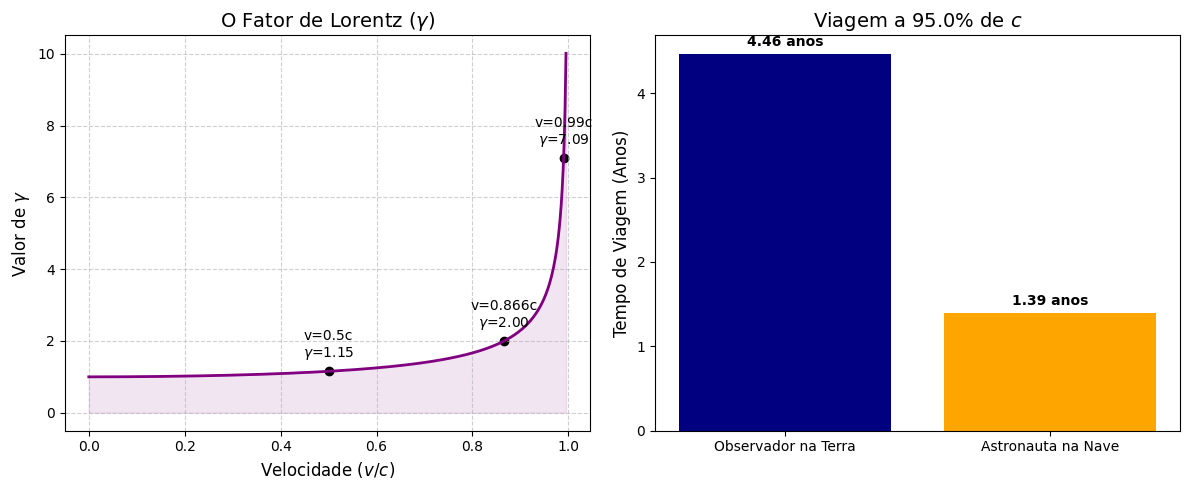

--- RELATÓRIO DA MISSÃO ---
Distância: 4.24 anos-luz
Velocidade da Nave: 95.0% da velocidade da luz
Fator de Lorentz (Gamma): 3.203
Para quem ficou na Terra, a viagem durou: 4.46 anos
Para o astronauta, a viagem durou apenas: 1.39 anos
Isso significa que o astronauta 'envelheceu' 3.07 anos a menos!


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. FUNÇÃO PARA O FATOR DE LORENTZ
# ==========================================
def calcular_gamma(v_sobre_c):
    """
    Calcula o fator de Lorentz gama.
    v_sobre_c: fração da velocidade da luz (v/c), entre 0 e 1.
    """
    # Usamos np.where para evitar divisões por zero ou valores inválidos no limite de c
    return 1 / np.sqrt(1 - v_sobre_c**2)

# Criando um array de velocidades de 0% a 99.5% da velocidade da luz
v_c = np.linspace(0, 0.995, 500)
gammas = calcular_gamma(v_c)

# ==========================================
# 2. PLOTAGEM DO GRÁFICO DE GAMMA
# ==========================================
plt.figure(figsize=(12, 5))

# Subplot 1: Comportamento do Fator de Lorentz
plt.subplot(1, 2, 1)
plt.plot(v_c, gammas, color='purple', linewidth=2)
plt.fill_between(v_c, gammas, color='purple', alpha=0.1) # Preenchimento estético

plt.title('O Fator de Lorentz ($\gamma$)', fontsize=14)
plt.xlabel('Velocidade ($v/c$)', fontsize=12)
plt.ylabel('Valor de $\gamma$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Destacando pontos interessantes para os alunos
pontos_v = [0.5, 0.866, 0.99] # 50%, 86.6% e 99% de c
for v in pontos_v:
    g = calcular_gamma(v)
    plt.scatter(v, g, color='black')
    plt.annotate(f'v={v}c\n$\gamma$={g:.2f}', (v, g), textcoords="offset points", xytext=(0,10), ha='center')

# ==========================================
# 3. EXEMPLO PRÁTICO: VIAGEM PARA PROXIMA CENTAURI
# ==========================================
# Distância até Proxima Centauri: ~4.24 anos-luz
distancia_ly = 4.24

# Vamos calcular o tempo de viagem para quem está na Terra e para o Astronauta
v_nave = 0.95 # Nave viajando a 95% da velocidade da luz
gamma_nave = calcular_gamma(v_nave)

tempo_terra = distancia_ly / v_nave
tempo_astronauta = tempo_terra / gamma_nave

# Subplot 2: Comparação de Tempo (Visualização de Barras)
plt.subplot(1, 2, 2)
labels = ['Observador na Terra', 'Astronauta na Nave']
tempos = [tempo_terra, tempo_astronauta]

barras = plt.bar(labels, tempos, color=['navy', 'orange'])
plt.ylabel('Tempo de Viagem (Anos)', fontsize=12)
plt.title(f'Viagem a {v_nave*100}% de $c$', fontsize=14)

# Adicionando os valores em cima das barras
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 0.1, f'{yval:.2f} anos', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Mensagem final explicativa para imprimir no console do Colab
print(f"--- RELATÓRIO DA MISSÃO ---")
print(f"Distância: {distancia_ly} anos-luz")
print(f"Velocidade da Nave: {v_nave*100}% da velocidade da luz")
print(f"Fator de Lorentz (Gamma): {gamma_nave:.3f}")
print(f"Para quem ficou na Terra, a viagem durou: {tempo_terra:.2f} anos")
print(f"Para o astronauta, a viagem durou apenas: {tempo_astronauta:.2f} anos")
print(f"Isso significa que o astronauta 'envelheceu' {tempo_terra - tempo_astronauta:.2f} anos a menos!")

# 5. Física Moderna: Decaimento Radioativo (Simulação de Monte Carlo)

Na física clássica, se conhecemos as condições iniciais de um sistema, podemos prever exatamente o seu futuro. Na mecânica quântica e na física nuclear, isso não é possível. O decaimento de um núcleo radioativo é um processo **puramente probabilístico**. Não podemos prever *quando* um átomo específico vai decair, mas podemos prever o comportamento de um grupo muito grande de átomos.

A lei do decaimento radioativo nos diz que a taxa de decaimento é proporcional ao número de átomos presentes:

$$\frac{dN}{dt} = -\lambda N$$

Onde $\lambda$ é a constante de decaimento. A solução teórica (macroscópica) para essa equação é a famosa curva exponencial:

$$N(t) = N_0 e^{-\lambda t}$$

O **Tempo de Meia-Vida ($t_{1/2}$)** é o tempo necessário para que metade da amostra decaia. A relação entre a constante de decaimento e a meia-vida é:

$$t_{1/2} = \frac{\ln(2)}{\lambda}$$

### O que vamos fazer no código?
Em vez de apenas desenhar a fórmula teórica, vamos **simular a realidade**. Vamos começar com uma amostra de 1000 átomos. A cada segundo, vamos "jogar um dado" virtual para cada átomo sobrevivente. Se o número sorteado for menor que a probabilidade de decaimento, o átomo decai.

No final, vamos comparar a nossa simulação caótica (realidade quântica) com a linha teórica contínua.

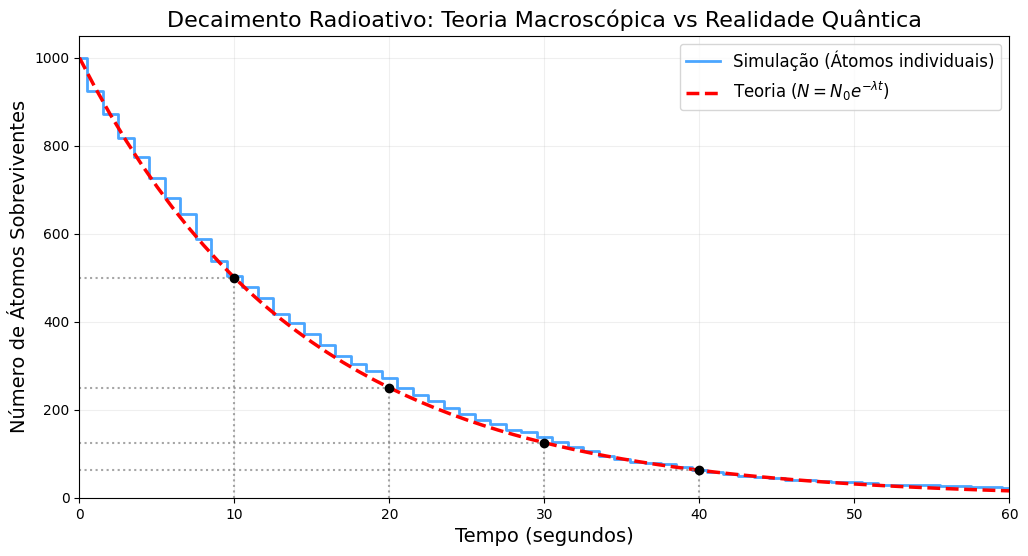

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. PARÂMETROS DA SIMULAÇÃO
# ==========================================
N0 = 1000               # Número inicial de átomos radioativos
t_meia_vida = 10.0      # Tempo de meia-vida (em segundos)

# Calculando a constante de decaimento (lambda)
lbda = np.log(2) / t_meia_vida

# Tempo total da simulação e tamanho do passo (dt = 1 segundo)
tempo_total = 60
tempos = np.arange(0, tempo_total + 1, 1)

# ==========================================
# 2. SIMULAÇÃO ESTOCÁSTICA (MONTE CARLO)
# ==========================================
# Array para guardar quantos átomos sobreviveram a cada segundo
N_simulado = np.zeros(len(tempos))
N_simulado[0] = N0

N_atual = N0

# A probabilidade de um átomo decair em 1 segundo é: p = 1 - e^(-lambda * dt)
prob_decair = 1 - np.exp(-lbda * 1)

# Loop passando segundo por segundo
for i in range(1, len(tempos)):
    # np.random.binomial joga uma "moeda viciada" para cada um dos N_atual átomos.
    # Retorna o número de átomos que "deram cara" (ou seja, que decaíram).
    decaimentos = np.random.binomial(N_atual, prob_decair)

    # Subtraímos os átomos que decaíram da nossa amostra atual
    N_atual -= decaimentos
    N_simulado[i] = N_atual

# ==========================================
# 3. CÁLCULO DA CURVA TEÓRICA
# ==========================================
# N(t) = N0 * e^(-lambda * t)
N_teorico = N0 * np.exp(-lbda * tempos)

# ==========================================
# 4. PLOTAGEM DOS RESULTADOS
# ==========================================
plt.figure(figsize=(12, 6))

# Plotando os dados da simulação (como pontos ou degraus, mostrando a natureza discreta)
plt.step(tempos, N_simulado, where='mid', label='Simulação (Átomos individuais)',
         color='dodgerblue', linewidth=2, alpha=0.8)

# Plotando a curva teórica (contínua)
plt.plot(tempos, N_teorico, label='Teoria ($N = N_0 e^{-\\lambda t}$)',
         color='red', linestyle='--', linewidth=2.5)

# Adicionando marcadores visuais para as Meias-Vidas
meias_vidas = [1, 2, 3, 4] # Vamos marcar as 4 primeiras meias-vidas
for mv in meias_vidas:
    t_mv = mv * t_meia_vida
    N_mv = N0 / (2**mv)
    # Linhas pontilhadas indicando o tempo e a quantidade
    plt.vlines(x=t_mv, ymin=0, ymax=N_mv, color='gray', linestyle=':', alpha=0.7)
    plt.hlines(y=N_mv, xmin=0, xmax=t_mv, color='gray', linestyle=':', alpha=0.7)
    plt.scatter(t_mv, N_mv, color='black', zorder=5) # Ponto preto na interseção

# Configurações estéticas do gráfico
plt.title('Decaimento Radioativo: Teoria Macroscópica vs Realidade Quântica', fontsize=16)
plt.xlabel('Tempo (segundos)', fontsize=14)
plt.ylabel('Número de Átomos Sobreviventes', fontsize=14)
plt.xlim(left=0, right=tempo_total)
plt.ylim(bottom=0, top=N0 + 50)
plt.legend(fontsize=12)
plt.grid(True, linestyle='-', alpha=0.2)

plt.show()